In [88]:
import pandas as pd
import requests
import gc
import numpy as np


import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

# GTEx miRNA

In [144]:
from pathlib import Path

shared_mirs = Path('/mnt/jack-5/amismailov/miRNA_study/inter_mir.txt').read_text().splitlines()
len(shared_mirs)

327

In [146]:
df_mir = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/GTEx_miRNA_counts.txt.gz')

In [147]:
URS = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/URS.csv', index_col=0) # URS miRNA + name

In [148]:
df_mir = df_mir.rename(columns={'Unnamed: 0' : 'miRNA'})
df_mir.index = df_mir.pop('miRNA')
df_mir.shape

(22482, 16761)

In [149]:
df_mir = df_mir[df_mir.index.str.contains('URS', na=False)]
df_mir

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS000012A1DD,0.000000,0.000000,1.996986,8.997750,0.000000,0.998424,0.999445,2.999279,33.999451,0.999768,...,0.000000,0.000000,45.998415,294.996801,0.000000,2.997920,97.999318,3.996688,0.000000,0.000000
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.000000
URS00003DB428,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.128780
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS000064189F,0.126507,0.195031,0.122076,0.000000,0.000000,0.000000,0.018519,0.052632,0.131324,0.041667,...,0.013699,0.000000,0.000000,0.000000,0.000000,0.030415,0.045455,0.000000,0.045478,0.000000
URS0000627203,2.643770,2.803830,2.571230,0.074561,0.265248,0.318487,2.808130,2.825030,1.650640,0.286723,...,1.607690,0.359743,0.260279,1.180280,1.164140,0.396345,0.282839,1.260370,0.295687,0.203162
URS0000693AA2,1.019050,2.189520,1.159150,0.009434,0.019238,1.009800,2.019610,0.000000,3.011240,0.000000,...,1.025000,0.009259,1.118170,0.008197,1.052290,0.047197,0.031549,0.074988,1.009260,0.024729


In [150]:
URS['miRNA_name'] = URS['miRNA_name'].str.lower()
URS

,URS,miRNA_name
0,URS00002B452B,hsa-mir-8-p1a_3p
1,URS000023B77E,hsa-mir-200a-5p
2,URS00003DB428,hsa-mir-8-p2a_3p
3,URS00001BB658,hsa-mir-8-p3a_5p
4,URS000055BBE5,hsa-mir-429
...,...,...
879,URS00001F7A91,hsa-mir-452-v1_3p
880,URS0000D523DA,hsa-mir-452-v1_5p
881,URS0000D52745,hsa-mir-105-p2_3p
882,URS0000D4F80A,hsa-mir-105-p2_5p


In [151]:
df_mir = df_mir.loc[URS['URS']]
df_mir

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
URS00002B452B,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000023B77E,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.000000
URS00003DB428,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.128780
URS00001BB658,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
URS000055BBE5,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
URS00001F7A91,0.000000,0.000000,0.000000,3.650532,0.000000,1.588045,10.836211,43.354140,3.507805,0.458893,...,5.918939,1.732778,4.580143,0.000000,0.189387,0.469969,24.389002,5.699008,0.000000,6.346705
URS0000D523DA,0.000000,19.228848,2.153108,53.367664,10.998178,32.723856,54.010793,380.964433,34.178929,4.768164,...,97.827640,15.893459,40.221381,26.267885,13.745760,14.248877,204.641367,42.735928,10.227119,46.628404
URS0000D52745,0.000000,2.998704,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [152]:
rename_URS = {}
for urs in df_mir.index.tolist():
    rename_URS.setdefault(urs, None)
    rename_URS[urs] = (URS[URS['URS'] == urs]['miRNA_name'].item()).lower()
rename_URS

{'URS00002B452B': 'hsa-mir-8-p1a_3p',
 'URS000023B77E': 'hsa-mir-200a-5p',
 'URS00003DB428': 'hsa-mir-8-p2a_3p',
 'URS00001BB658': 'hsa-mir-8-p3a_5p',
 'URS000055BBE5': 'hsa-mir-429',
 'URS00002E99CB': 'hsa-mir-551a',
 'URS0000EFE3BE': 'hsa-mir-551-p1_5p',
 'URS000040249F': 'hsa-mir-34-p1_3p',
 'URS000030BD69': 'hsa-mir-34a-5p',
 'URS0000EFC8B5': 'hsa-mir-552_3p',
 'URS00005AD632': 'hsa-mir-552_5p',
 'URS00001E2F7A': 'hsa-mir-5581-3p',
 'URS0000EFCFBB': 'hsa-mir-5581_5p',
 'URS00001B2024': 'hsa-mir-30-p1d_5p',
 'URS00004DC6A5': 'hsa-mir-30e-3p',
 'URS00000980C2': 'hsa-mir-30-p2b_5p',
 'URS0000237FB8': 'hsa-mir-30c-1-3p',
 'URS00005FF45E': 'hsa-mir-101-p2-v1_3p',
 'URS00004D302A': 'hsa-mir-101-p1-v1_5p',
 'URS000021D7C8': 'hsa-mir-186-3p',
 'URS000015CB3A': 'hsa-mir-186_5p',
 'URS0000D54A4C': 'hsa-mir-760_5p',
 'URS000075BD83': 'hsa-mir-760_3p',
 'URS0000EFF083': 'hsa-mir-137-p1-v2_3p',
 'URS000075D65A': 'hsa-mir-137-p1-v1_5p',
 'URS000020E2DD': 'hsa-mir-197-5p',
 'URS000061E740': 'hsa-

In [153]:
df_mir = df_mir.rename(index=rename_URS)
df_mir.head()

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a_3p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-200a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
hsa-mir-8-p2a_3p,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
hsa-mir-8-p3a_5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.00000


In [ ]:
df_mir.index = df_mir.index.str.replace('_', '-', regex=False).str.lower()
df_mir.head()

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-mir-8-p1a-3p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-200a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.542499,0.000000,...,0.000000,0.000000,276.985711,789.887832,0.000000,0.000000,140.604582,0.000000,0.000000,0.00000
hsa-mir-8-p2a-3p,0.433135,17.083220,25.965643,68.054364,1.892842,0.197676,2.217536,10.632999,926.520317,8.381936,...,3.885708,4.401099,1216.693192,7181.571570,11.039381,8.041172,1068.452809,259.913674,0.505608,0.12878
hsa-mir-8-p3a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
hsa-mir-429,0.774451,2.101293,9.824298,31.135534,0.000000,0.000000,0.047191,2.762032,176.056573,0.000000,...,0.000000,0.000000,309.278472,1676.506972,5.446238,0.000000,711.828854,78.311675,0.000000,0.00000


In [156]:
df_mir = df_mir.loc[shared_mirs]
df_mir.shape

(327, 16761)

In [157]:
counts_per_sample = df_mir.sum(axis=0)
cpm = df_mir.divide(counts_per_sample, axis=1) * 1e6
cpm = cpm.fillna(0.0)
cpm.shape

(327, 16761)

In [158]:
cpm.head()

,GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0526-SM-F5BAM,GTEX-1117F-0726-SM-F1C1K,GTEX-1117F-1326-SM-EVR9C,GTEX-1117F-1426-SM-GMKK4,GTEX-1117F-2426-SM-EV6SY,...,GTEX-ZZPU-1126-SM-F413N,GTEX-ZZPU-1226-SM-EBB7I,GTEX-ZZPU-1326-SM-DEURN,GTEX-ZZPU-1426-SM-EAW6B,GTEX-ZZPU-1826-SM-EV6W1,GTEX-ZZPU-2126-SM-DEUQ2,GTEX-ZZPU-2226-SM-EAIMP,GTEX-ZZPU-2426-SM-GEGOG,GTEX-ZZPU-2626-SM-F4GMZ,GTEX-ZZPU-2726-SM-GEUZU
miRNA,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,0.000000,2.732167,2.771319,2.740528,0.000000,0.000000,4.057141,9.073236,0.000000,0.000000,...,18.002224,6.102508,1.261597,5.270488,2.840625,1.335898,0.000000,2.920467,3.449547,0.000000
hsa-let-7a-3p,15.001399,146.162420,311.382079,73.898017,489.241589,292.309524,215.024968,181.433743,138.800987,115.896951,...,110.740170,363.099197,150.187175,119.053350,176.120278,124.260831,288.249383,445.587050,227.680537,653.793458
hsa-let-7a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b-5p,53509.498512,10343.703384,16282.020615,17557.190311,23062.684222,46916.739581,32161.528480,41530.940619,29665.334873,34671.822581,...,39765.948154,32762.676609,13832.295124,33063.971039,42719.509687,22898.789251,38966.116391,78047.338215,54144.468909,146563.451952
hsa-let-7c-3p,0.000000,11.273100,8.315189,13.711287,12.806609,6.046493,2.027719,4.535381,2.312688,0.000000,...,19.386208,3.046268,3.785677,3.159903,1.419340,2.671744,9.939617,5.840753,13.801276,22.162254


In [159]:
set_mir = cpm.columns.tolist()
cols = ['SAMPID', 'SMTS', 'SMTSD']

annotation = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/annotation.txt', low_memory=False)

mir_annot_cols = annotation[annotation['SAMPID'].isin(set_mir)][cols]
mir_annot_cols

,SAMPID,SMTS,SMTSD
1634,GTEX-1117F-0005-SM-GMJZF,Blood,Whole Blood
1643,GTEX-1117F-0011-R3a-SM-GM3E3,Brain,Brain - Anterior cingulate cortex (BA24)
1647,GTEX-1117F-0011-R7a-SM-GLFXK,Brain,Brain - Putamen (basal ganglia)
1651,GTEX-1117F-0226-SM-DEURW,Adipose Tissue,Adipose - Subcutaneous
1653,GTEX-1117F-0426-SM-GAPMD,Muscle,Muscle - Skeletal
...,...,...,...
48001,GTEX-ZZPU-2126-SM-DEUQ2,Ovary,Ovary
48004,GTEX-ZZPU-2226-SM-EAIMP,Vagina,Vagina
48008,GTEX-ZZPU-2426-SM-GEGOG,Blood Vessel,Artery - Tibial
48011,GTEX-ZZPU-2626-SM-F4GMZ,Muscle,Muscle - Skeletal


In [160]:
cpm = cpm.transpose() 
cpm.insert(0, 'SAMPID', cpm.index.tolist()) 
cpm.head()

miRNA,SAMPID,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,hsa-let-7e-5p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
GTEX-1117F-0005-SM-GMJZF,GTEX-1117F-0005-SM-GMJZF,0.000000,15.001399,0.0,53509.498512,0.000000,0.0,3441.206184,0.000000,0.000000,...,97.691485,319677.051334,1863.641807,8006.712505,14.520650,14.712131,56.721410,7486.092241,7.466594,955.223276
GTEX-1117F-0011-R3a-SM-GM3E3,GTEX-1117F-0011-R3a-SM-GM3E3,2.732167,146.162420,0.0,10343.703384,11.273100,0.0,1562.263137,37.740554,184.204946,...,1.023122,957.812271,1946.908693,372.447486,2796.641321,0.000000,4098.723166,251112.859861,370.256556,5973.705813
GTEX-1117F-0011-R7a-SM-GLFXK,GTEX-1117F-0011-R7a-SM-GLFXK,2.771319,311.382079,0.0,16282.020615,8.315189,0.0,2081.598723,37.414733,267.087720,...,6.467673,2536.813433,2131.229422,499.195664,3439.428351,2.338920,2591.163698,164601.841551,402.823173,7837.959462
GTEX-1117F-0226-SM-DEURW,GTEX-1117F-0226-SM-DEURW,2.740528,73.898017,0.0,17557.190311,13.711287,0.0,1074.668236,19.168715,36.335213,...,87.787493,3465.389352,271.090792,393.274873,435.774734,36.423276,1954.063553,427480.523602,260.329915,6863.645652
GTEX-1117F-0426-SM-GAPMD,GTEX-1117F-0426-SM-GAPMD,0.000000,489.241589,0.0,23062.684222,12.806609,0.0,6900.098090,2.544264,121.946437,...,105.037125,8787.295552,115.007736,510.220616,14967.785723,37.446307,2062.086489,102390.776277,89.518407,2592.525619


In [161]:
cpm = pd.merge(
    cpm,
    mir_annot_cols[['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)

In [ ]:
cpm.insert(0, 'SMTSD', cpm.pop('SMTSD'))
cpm = cpm.sort_values('SMTSD')
cpm.head()

,SMTSD,SAMPID,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
16760,Adipose - Subcutaneous,GTEX-ZZPU-2726-SM-GEUZU,0.000000,653.793458,0.0,146563.451952,22.162254,0.0,4074.724937,33.208724,...,155.186774,9774.300459,847.246445,723.737498,516.834513,0.000000,4162.369808,171734.021470,376.500614,10598.220513
10256,Adipose - Subcutaneous,GTEX-1MCC2-2326-SM-G8KT6,3.324882,472.380961,0.0,55774.689461,3.321645,0.0,2242.749188,29.914752,...,83.192951,8578.508646,304.923767,560.599481,406.100761,0.000000,2707.312398,235111.649435,305.859660,9402.224444
6815,Adipose - Subcutaneous,GTEX-1EH9U-0226-SM-GGQRX,4.434429,368.114175,0.0,98459.045832,13.305507,0.0,5751.712406,15.499899,...,130.883328,13363.997434,724.792637,597.519515,1009.010176,5.040700,4585.940158,132853.286932,336.954467,9649.476417
2154,Adipose - Subcutaneous,GTEX-13FTY-0626-SM-F55HH,0.000000,229.177699,0.0,66041.361635,13.023661,0.0,2124.024621,6.493219,...,31.262863,5775.405366,533.267200,776.702372,425.475120,0.000000,2950.256789,227984.372391,359.377939,7263.601907
6769,Adipose - Subcutaneous,GTEX-1E1VI-0226-SM-G5R3G,0.000000,465.118917,0.0,71096.321672,0.000000,0.0,3437.046683,73.620502,...,37.401447,9761.755734,689.777180,1111.872901,524.418337,0.190837,2677.908667,133946.007123,472.070370,10111.119093


In [163]:
import gc
del df_mir
gc.collect()

17

In [164]:
from collections import Counter
temp = dict(Counter(cpm.columns.tolist()))
temp = [k for k, v in temp.items() if v > 1]

cpm = cpm.loc[:, ~cpm.columns.isin(temp)]
cpm.head()

,SMTSD,SAMPID,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
16760,Adipose - Subcutaneous,GTEX-ZZPU-2726-SM-GEUZU,0.000000,653.793458,0.0,146563.451952,22.162254,0.0,4074.724937,33.208724,...,155.186774,9774.300459,847.246445,723.737498,516.834513,0.000000,4162.369808,171734.021470,376.500614,10598.220513
10256,Adipose - Subcutaneous,GTEX-1MCC2-2326-SM-G8KT6,3.324882,472.380961,0.0,55774.689461,3.321645,0.0,2242.749188,29.914752,...,83.192951,8578.508646,304.923767,560.599481,406.100761,0.000000,2707.312398,235111.649435,305.859660,9402.224444
6815,Adipose - Subcutaneous,GTEX-1EH9U-0226-SM-GGQRX,4.434429,368.114175,0.0,98459.045832,13.305507,0.0,5751.712406,15.499899,...,130.883328,13363.997434,724.792637,597.519515,1009.010176,5.040700,4585.940158,132853.286932,336.954467,9649.476417
2154,Adipose - Subcutaneous,GTEX-13FTY-0626-SM-F55HH,0.000000,229.177699,0.0,66041.361635,13.023661,0.0,2124.024621,6.493219,...,31.262863,5775.405366,533.267200,776.702372,425.475120,0.000000,2950.256789,227984.372391,359.377939,7263.601907
6769,Adipose - Subcutaneous,GTEX-1E1VI-0226-SM-G5R3G,0.000000,465.118917,0.0,71096.321672,0.000000,0.0,3437.046683,73.620502,...,37.401447,9761.755734,689.777180,1111.872901,524.418337,0.190837,2677.908667,133946.007123,472.070370,10111.119093


In [165]:
cpm.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/gtex_mir_cpm_mature.parquet')

# TCGA mir

In [166]:
import pandas as pd
df_mir = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/FullTCGA/TCGA_mature_raw_matrix.csv')
df_mir.index = df_mir.pop('miRNA_ID')

In [169]:
df_mir.head()

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,18,5,6,0,10,2,7,0,5,4,...,12,11,1,0,0,22,1,0,13,0
hsa-let-7a-3p,610,24,254,49,529,40,443,2,472,47,...,62,221,102,97,56,45,52,18,35,34
hsa-let-7a-5p,714058,33714,402474,35163,378334,41192,288250,597,578010,33894,...,493614,297685,478589,227549,245402,335432,460243,114327,320471,257608
hsa-let-7b-3p,225,10,35,9,62,4,56,1,51,4,...,20,109,61,131,44,76,46,9,57,50
hsa-let-7b-5p,179966,7793,22271,2683,32585,4141,34126,175,41815,3920,...,82298,109632,118537,122648,41267,173343,201663,23972,138631,134493


In [170]:
df_mir.index = df_mir.index.str.replace('_', '-', regex=False).str.lower()
df_mir.head()

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,18,5,6,0,10,2,7,0,5,4,...,12,11,1,0,0,22,1,0,13,0
hsa-let-7a-3p,610,24,254,49,529,40,443,2,472,47,...,62,221,102,97,56,45,52,18,35,34
hsa-let-7a-5p,714058,33714,402474,35163,378334,41192,288250,597,578010,33894,...,493614,297685,478589,227549,245402,335432,460243,114327,320471,257608
hsa-let-7b-3p,225,10,35,9,62,4,56,1,51,4,...,20,109,61,131,44,76,46,9,57,50
hsa-let-7b-5p,179966,7793,22271,2683,32585,4141,34126,175,41815,3920,...,82298,109632,118537,122648,41267,173343,201663,23972,138631,134493


In [171]:
df_mir=df_mir.loc[shared_mirs]
df_mir.shape

(327, 15964)

In [172]:
counts_per_sample = df_mir.sum(axis=0)
cpm_tcga = df_mir.divide(counts_per_sample, axis=1) * 1e6
cpm_tcga = cpm_tcga.fillna(0.0)
cpm_tcga.shape

(327, 15964)

In [173]:
cpm_tcga

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,1.586508,6.942034,1.130046,0.000000,2.524994,2.656191,1.411532,0.000000,0.755251,4.726641,...,4.027038,2.972231,0.418747,0.000000,0.000000,2.018722,0.347579,0.000000,5.166802,0.000000
hsa-let-7a-3p,53.764981,33.321763,47.838608,54.311141,133.572198,53.123813,89.329807,66.048017,71.295701,55.538028,...,20.806361,59.714817,42.712244,54.905681,27.845056,4.129203,18.074113,14.147240,13.910621,15.210867
hsa-let-7a-5p,62936.581561,46808.746963,75802.346691,38974.339649,95529.118865,54706.902643,58124.868551,19715.333047,87308.534413,40051.189518,...,165650.175277,80435.318315,200407.943807,128801.369359,122022.008534,30779.265086,159970.845066,89856.193308,127370.022134,115248.268198
hsa-let-7b-5p,15862.079603,10819.854217,4194.541916,2973.812055,8227.693885,5499.642742,6881.419824,5779.201479,6316.164714,4632.107834,...,27618.094553,29622.872558,49637.071548,69423.422424,20519.320243,15905.966479,70093.842880,18840.979523,55098.381877,60169.270111
hsa-let-7c-3p,1.850926,2.776814,2.825115,7.758734,3.787491,3.984286,4.637891,0.000000,4.682557,10.634941,...,72.822262,20.805615,9.212445,5.094342,55.192879,23.857619,53.874760,51.873212,91.412655,141.818969
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-96-5p,12.163225,22.214509,19.775803,86.454469,6.564985,29.218097,10.284018,0.000000,11.177716,7.089961,...,1.342346,0.540406,0.837495,1.698114,0.497233,558.543569,82.376245,1.571916,2.782124,0.000000
hsa-mir-98-5p,114.052271,234.640750,146.152599,356.901782,122.714722,221.791919,92.757813,165.120042,120.235971,249.330294,...,200.345117,130.778152,157.867805,83.207579,92.485365,73.132779,90.370564,99.816636,102.143706,135.108292
hsa-mir-99a-5p,165.173073,134.675460,200.018118,287.073173,179.274594,231.088587,227.861584,561.408144,191.833772,187.883966,...,3788.435556,865.189342,479.047132,204.339700,8268.987221,566.159656,4503.929903,909.353133,8237.075145,5587.309484


In [174]:
cpm_tcga.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tcga_mir_cpm_mature.parquet')

# GTEx mRNA

In [2]:
import pandas as pd
shared_features = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/features.txt', header=None)[0].tolist()
len(shared_features)

17392

In [3]:
df_genes_gtex = pd.read_csv(
    '/mnt/jack-5/amismailov/miRNA_study/GTEX_genex_counts.gct.gz',
    sep='\t',
    skiprows=2,
    low_memory=False
)

print(df_genes_gtex.shape)
df_genes_gtex.head(5)

(59033, 19790)


,Name,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
0,ENSG00000223972.5,DDX11L1,0,0,0,0,0,1,0,2,...,0,0,0,0,0,0,0,1,1,1
1,ENSG00000227232.5,WASH7P,54,117,457,183,167,223,202,224,...,135,79,86,81,47,89,83,220,32,66
2,ENSG00000278267.1,MIR6859-1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,ENSG00000243485.5,MIR1302-2HG,0,2,1,0,0,1,0,0,...,1,0,2,2,0,1,1,0,0,0
4,ENSG00000237613.2,FAM138A,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
del_suff = lambda x: x.split('.')[0]
df_genes_gtex['Name'] = df_genes_gtex['Name'].apply(del_suff)
df_genes_gtex.index = df_genes_gtex.pop('Name')
df_genes_gtex = df_genes_gtex.loc[shared_features]
print(df_genes_gtex.shape)
df_genes_gtex.head()

(17392, 19789)


,Description,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,TSPAN6,20,1322,514,1483,1250,1348,2421,2827,2096,...,1473,1142,553,7515,2502,4114,574,1537,245,3501
ENSG00000000005,TNMD,0,4,2,6,31,11,2,3,2,...,8,6,5,78,0,61,4,504,302,1147
ENSG00000000419,DPM1,98,1018,1091,827,790,834,1355,1520,1146,...,1076,1281,1490,1336,1069,1822,1441,1752,1308,1331
ENSG00000000457,SCYL3,59,370,580,244,365,478,532,483,404,...,1030,700,756,922,661,1446,756,1634,948,1187
ENSG00000000460,C1orf112,14,94,296,122,79,213,195,233,128,...,260,127,240,319,300,368,182,332,98,381


In [5]:
df_genes_gtex.pop('Description')
df_genes_gtex.head()

,GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R4b-SM-GI4VM,GTEX-1117F-0011-R5a-SM-GI4VW,GTEX-1117F-0011-R6a-SM-GI4VX,GTEX-1117F-0011-R7a-SM-H65ZK,GTEX-1117F-0226-SM-5GZZ7,...,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2326-SM-GOQYU,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2526-SM-GOQZ3,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
Name,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,20,1322,514,1483,1250,1348,2421,2827,2096,2255,...,1473,1142,553,7515,2502,4114,574,1537,245,3501
ENSG00000000005,0,4,2,6,31,11,2,3,2,428,...,8,6,5,78,0,61,4,504,302,1147
ENSG00000000419,98,1018,1091,827,790,834,1355,1520,1146,1220,...,1076,1281,1490,1336,1069,1822,1441,1752,1308,1331
ENSG00000000457,59,370,580,244,365,478,532,483,404,658,...,1030,700,756,922,661,1446,756,1634,948,1187
ENSG00000000460,14,94,296,122,79,213,195,233,128,172,...,260,127,240,319,300,368,182,332,98,381


In [6]:
df_genes_gtex = df_genes_gtex.T
df_genes_gtex.insert(0, 'SAMPID', df_genes_gtex.index)
df_genes_gtex.head()

Name,SAMPID,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
GTEX-1117F-0005-SM-HL9SH,GTEX-1117F-0005-SM-HL9SH,20,0,98,59,14,7816,82,209,482,...,0,210,67,0,0,15,3,0,0,0
GTEX-1117F-0011-R10b-SM-GI4VE,GTEX-1117F-0011-R10b-SM-GI4VE,1322,4,1018,370,94,548,1457,670,2120,...,0,3311,185,0,2,32,0,0,0,0
GTEX-1117F-0011-R11b-SM-GIN8R,GTEX-1117F-0011-R11b-SM-GIN8R,514,2,1091,580,296,278,818,544,1287,...,0,1667,103,0,5,47,0,0,0,0
GTEX-1117F-0011-R2b-SM-GI4VL,GTEX-1117F-0011-R2b-SM-GI4VL,1483,6,827,244,122,412,1403,1329,2401,...,0,2720,110,0,2,56,1,0,2,0
GTEX-1117F-0011-R3a-SM-GJ3PJ,GTEX-1117F-0011-R3a-SM-GJ3PJ,1250,31,790,365,79,193,573,845,1815,...,0,7435,163,0,3,64,0,0,0,0


In [7]:
annotation = pd.read_table('/mnt/jack-5/amismailov/miRNA_study/annotation.txt', low_memory=False)
annotation[annotation['SAMPID'].isin(df_genes_gtex.index)][['SAMPID', 'SMTSD']]

,SAMPID,SMTSD
1635,GTEX-1117F-0005-SM-HL9SH,Whole Blood
1638,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9)
1640,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere
1641,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra
1642,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24)
...,...,...
48005,GTEX-ZZPU-2326-SM-GOQYU,Nerve - Tibial
48006,GTEX-ZZPU-2426-SM-5E44I,Artery - Tibial
48009,GTEX-ZZPU-2526-SM-GOQZ3,Skin - Sun Exposed (Lower leg)
48010,GTEX-ZZPU-2626-SM-5E45Y,Muscle - Skeletal


In [8]:
df_genes_gtex = pd.merge(
    df_genes_gtex,
    annotation[annotation['SAMPID'].isin(df_genes_gtex.index)][['SAMPID', 'SMTSD']],
    on='SAMPID',
    how='left',      
    validate='one_to_one'  
)

In [9]:
df_genes_gtex.insert(1, 'SMTSD', df_genes_gtex.pop('SMTSD'))
df_genes_gtex.head()


,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
0,GTEX-1117F-0005-SM-HL9SH,Whole Blood,20,0,98,59,14,7816,82,209,...,0,210,67,0,0,15,3,0,0,0
1,GTEX-1117F-0011-R10b-SM-GI4VE,Brain - Frontal Cortex (BA9),1322,4,1018,370,94,548,1457,670,...,0,3311,185,0,2,32,0,0,0,0
2,GTEX-1117F-0011-R11b-SM-GIN8R,Brain - Cerebellar Hemisphere,514,2,1091,580,296,278,818,544,...,0,1667,103,0,5,47,0,0,0,0
3,GTEX-1117F-0011-R2b-SM-GI4VL,Brain - Substantia nigra,1483,6,827,244,122,412,1403,1329,...,0,2720,110,0,2,56,1,0,2,0
4,GTEX-1117F-0011-R3a-SM-GJ3PJ,Brain - Anterior cingulate cortex (BA24),1250,31,790,365,79,193,573,845,...,0,7435,163,0,3,64,0,0,0,0


In [10]:
df_genes_gtex = df_genes_gtex.sort_values(by='SMTSD')
df_genes_gtex.head()

,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,GTEX-ZZPU-2726-SM-5NQ8O,Adipose - Subcutaneous,3501,1147,1331,1187,381,2167,10305,3121,...,0,212,456,0,1,26,0,2,2,0
11303,GTEX-1J8EW-0226-SM-CYPSW,Adipose - Subcutaneous,3123,1287,1359,1081,397,1438,10324,2965,...,0,506,373,0,2,56,0,0,0,0
11293,GTEX-1J1R8-2226-SM-ARZMP,Adipose - Subcutaneous,2134,1647,1300,784,228,1828,25823,1842,...,0,582,294,0,2,40,0,3,0,0
11252,GTEX-1J1OQ-0326-SM-CYPTJ,Adipose - Subcutaneous,3417,220,1311,618,213,7165,3432,1949,...,0,257,206,0,0,29,0,0,0,0
11222,GTEX-1IY9M-0226-SM-CMKHP,Adipose - Subcutaneous,1995,8630,1627,959,313,545,14945,3140,...,0,295,381,0,0,51,0,1,0,0


In [11]:
df_genes_gtex['SMTSD'] = (
    df_genes_gtex.groupby('SMTSD')
    .cumcount()
    .astype(str)
    .radd(df_genes_gtex['SMTSD'] + '_')
)

In [12]:
df_genes_gtex

,SAMPID,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,GTEX-ZZPU-2726-SM-5NQ8O,Adipose - Subcutaneous_0,3501,1147,1331,1187,381,2167,10305,3121,...,0,212,456,0,1,26,0,2,2,0
11303,GTEX-1J8EW-0226-SM-CYPSW,Adipose - Subcutaneous_1,3123,1287,1359,1081,397,1438,10324,2965,...,0,506,373,0,2,56,0,0,0,0
11293,GTEX-1J1R8-2226-SM-ARZMP,Adipose - Subcutaneous_2,2134,1647,1300,784,228,1828,25823,1842,...,0,582,294,0,2,40,0,3,0,0
11252,GTEX-1J1OQ-0326-SM-CYPTJ,Adipose - Subcutaneous_3,3417,220,1311,618,213,7165,3432,1949,...,0,257,206,0,0,29,0,0,0,0
11222,GTEX-1IY9M-0226-SM-CMKHP,Adipose - Subcutaneous_4,1995,8630,1627,959,313,545,14945,3140,...,0,295,381,0,0,51,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8085,GTEX-1C64O-0006-SM-7PC22,Whole Blood_798,8,8,712,884,68,129363,131,1109,...,0,1920,125,0,0,27,3,0,0,0
8111,GTEX-1C6VQ-0005-SM-7P8OR,Whole Blood_799,4,2,64,40,24,7124,24,69,...,0,113,21,0,0,2,2,0,4,0
18893,GTEX-ZG7Y-0006-SM-4WWEA,Whole Blood_800,8,2,327,380,26,154944,54,333,...,0,274,42,0,0,24,19,0,0,0
459,GTEX-11EM3-0005-SM-5N9DK,Whole Blood_801,11,0,588,927,74,81966,24,497,...,0,1108,147,0,0,9,1,0,2,0


In [13]:
df_genes_gtex.pop('SAMPID')
df_genes_gtex.head(5)

,SMTSD,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
19787,Adipose - Subcutaneous_0,3501,1147,1331,1187,381,2167,10305,3121,4138,...,0,212,456,0,1,26,0,2,2,0
11303,Adipose - Subcutaneous_1,3123,1287,1359,1081,397,1438,10324,2965,1951,...,0,506,373,0,2,56,0,0,0,0
11293,Adipose - Subcutaneous_2,2134,1647,1300,784,228,1828,25823,1842,1306,...,0,582,294,0,2,40,0,3,0,0
11252,Adipose - Subcutaneous_3,3417,220,1311,618,213,7165,3432,1949,1947,...,0,257,206,0,0,29,0,0,0,0
11222,Adipose - Subcutaneous_4,1995,8630,1627,959,313,545,14945,3140,1987,...,0,295,381,0,0,51,0,1,0,0


In [15]:
df_genes_gtex.index = df_genes_gtex.pop('SMTSD')
df_genes_gtex = df_genes_gtex.transpose()
df_genes_gtex.head(5)

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
ENSG00000000003,3501,3123,2134,3417,1995,4400,2800,2958,5008,2168,...,4,6,11,7,9,8,4,8,11,20
ENSG00000000005,1147,1287,1647,220,8630,1531,1584,1969,2061,784,...,0,0,2,0,0,8,2,2,0,0
ENSG00000000419,1331,1359,1300,1311,1627,1832,1605,1758,1678,1421,...,324,182,226,223,406,712,64,327,588,98
ENSG00000000457,1187,1081,784,618,959,920,770,1538,1074,941,...,166,288,285,259,386,884,40,380,927,59
ENSG00000000460,381,397,228,213,313,302,252,576,470,366,...,119,137,92,67,139,68,24,26,74,14


In [16]:
df_genes_gtex.shape

(17392, 19788)

In [17]:
# gene length
gene_length = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet')
print(f'size: {gene_length.shape}')
gene_length.index = gene_length.pop('gene_id')
gene_length.head(2)

size: (78899, 3)


,gene_name,gene_length_kb
gene_id,,
ENSG00000142611,PRDM16,369.454
ENSG00000284616,None,5.467


In [18]:
share = set(df_genes_gtex.index.tolist()) & set(gene_length.index.tolist())
len(share)

17392

In [19]:
sorted_features = sorted(df_genes_gtex.index.tolist())
df_genes_gtex = df_genes_gtex.loc[sorted_features]
gene_length = gene_length.loc[sorted_features]

In [20]:
gene_length.head()

,gene_name,gene_length_kb
gene_id,,
ENSG00000000003,TSPAN6,12.884
ENSG00000000005,TNMD,14.950
ENSG00000000419,DPM1,24.289
ENSG00000000457,SCYL3,47.287
ENSG00000000460,FIRRM,193.450


In [21]:
gene_length.insert(0, 'gene_id', gene_length.index)
gene_length.head()

,gene_id,gene_name,gene_length_kb
gene_id,,,
ENSG00000000003,ENSG00000000003,TSPAN6,12.884
ENSG00000000005,ENSG00000000005,TNMD,14.950
ENSG00000000419,ENSG00000000419,DPM1,24.289
ENSG00000000457,ENSG00000000457,SCYL3,47.287
ENSG00000000460,ENSG00000000460,FIRRM,193.450


In [22]:
lengths = gene_length.set_index('gene_id')['gene_length_kb']
lengths

gene_id
ENSG00000000003     12.884
ENSG00000000005     14.950
ENSG00000000419     24.289
ENSG00000000457     47.287
ENSG00000000460    193.450
                    ...   
ENSG00000286264      3.038
ENSG00000286522      0.511
ENSG00000286920      5.652
ENSG00000287080      0.486
ENSG00000287585      0.630
Name: gene_length_kb, Length: 17392, dtype: float64

In [23]:
L = lengths.reindex(df_genes_gtex.index) # double check
L

ENSG00000000003     12.884
ENSG00000000005     14.950
ENSG00000000419     24.289
ENSG00000000457     47.287
ENSG00000000460    193.450
                    ...   
ENSG00000286264      3.038
ENSG00000286522      0.511
ENSG00000286920      5.652
ENSG00000287080      0.486
ENSG00000287585      0.630
Name: gene_length_kb, Length: 17392, dtype: float64

In [25]:
import numpy as np
rpk_gtex = df_genes_gtex.div(L, axis=0)
scale = rpk_gtex.sum(axis=0).replace(0, np.nan)
tpm_gtex = rpk_gtex.div(scale, axis=1) * 1e6
tpm_gtex = tpm_gtex.fillna(0.0)
tpm_gtex

SMTSD,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.828559,1.707732,1.678423,0.649941,2.129211,0.975302,2.884198,3.499356,1.460182,2.134847,...,0.431405,2.096918,2.433283,0.207534,1.350489,1.110938,0.057311,1.120895,0.474701,0.413111
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.578335,5.169082,0.459250,0.411277,0.917593,0.733862,0.340728,5.275626,0.313577,0.491206
ENSG00000286920,0.034258,0.000000,0.067663,0.000000,0.022441,0.000000,0.000000,0.000000,0.000000,0.024415,...,0.000000,0.000000,0.041521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.398411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.244644,3.516753,2.897242,0.432433,1.447191,0.000000,0.716510,0.000000,0.659415,0.000000


In [29]:
import gc
gc.collect()

1950

In [124]:
tpm_gtex.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_gtex.parquet')

In [176]:
tpm_gtex = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_gtex.parquet')

# TCGA mRNA

In [127]:
df_rna_tcga = pd.read_csv('/mnt/jack-5/amismailov/miRNA_study/FullTCGA/FULL_RNA_expr_counts_raw.csv')

df_rna_tcga['gene_id'] = df_rna_tcga['gene_id'].apply(del_suff)
df_rna_tcga.index = df_rna_tcga.pop('gene_id')
df_rna_tcga = df_rna_tcga.loc[sorted_features]
df_rna_tcga.head(5)

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,108,52,53,56,82,15,91,26,146,93,...,1112,714,981,851,2895,1374,816,2204,381,539
ENSG00000000005,1,2,0,1,0,4,0,0,1,3,...,0,0,0,0,6,0,1,0,0,0
ENSG00000000419,1855,615,718,388,2362,652,2907,511,2143,500,...,274,536,594,1119,1338,937,372,726,268,182
ENSG00000000457,1367,1383,1199,1092,1274,1297,1419,1207,1127,1012,...,152,304,287,499,647,547,163,463,165,200
ENSG00000000460,1871,1632,1576,1234,2765,1841,2868,1610,2562,1547,...,47,52,119,186,339,145,56,151,49,48


In [128]:
# gene length
gene_length = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/df_gene_mapping.parquet')
print(f'size: {gene_length.shape}')
gene_length.index = gene_length.pop('gene_id')
gene_length.head()

size: (78899, 3)


,gene_name,gene_length_kb
gene_id,,
ENSG00000142611,PRDM16,369.454
ENSG00000284616,None,5.467
ENSG00000260972,None,1.697
ENSG00000229280,EEF1DP6,0.372
ENSG00000232596,LINC01646,22.536


In [130]:
share = set(df_rna_tcga.index.tolist()) & set(gene_length.index.tolist())
len(share)

17392

In [131]:
df_rna_tcga = df_rna_tcga.loc[sorted_features]
gene_length = gene_length.loc[sorted_features]

In [133]:
gene_length.head(5)

,gene_name,gene_length_kb
gene_id,,
ENSG00000000003,TSPAN6,12.884
ENSG00000000005,TNMD,14.950
ENSG00000000419,DPM1,24.289
ENSG00000000457,SCYL3,47.287
ENSG00000000460,FIRRM,193.450


In [134]:
gene_length.insert(0, 'gene_id', gene_length.index)
gene_length.head()

,gene_id,gene_name,gene_length_kb
gene_id,,,
ENSG00000000003,ENSG00000000003,TSPAN6,12.884
ENSG00000000005,ENSG00000000005,TNMD,14.950
ENSG00000000419,ENSG00000000419,DPM1,24.289
ENSG00000000457,ENSG00000000457,SCYL3,47.287
ENSG00000000460,ENSG00000000460,FIRRM,193.450


In [135]:
lengths = gene_length.set_index('gene_id')['gene_length_kb']
L = lengths.reindex(df_rna_tcga.index) # double check

In [136]:
rpk_tcga = df_rna_tcga.div(L, axis=0)
scale = rpk_tcga.sum(axis=0).replace(0, np.nan)
tpm_tcga = rpk_tcga.div(scale, axis=1) * 1e6
tpm_tcga = tpm_tcga.fillna(0.0)
tpm_tcga.head(5)

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003,1.238773,1.862452,1.181761,2.498223,0.838961,0.422033,0.810094,0.777200,1.534297,3.108085,...,12.511553,11.507558,9.771230,5.449564,22.532695,16.906433,16.131404,20.225193,4.423699,7.886002
ENSG00000000005,0.009885,0.061734,0.000000,0.038446,0.000000,0.096990,0.000000,0.000000,0.009057,0.086405,...,0.000000,0.000000,0.000000,0.000000,0.040246,0.000000,0.017037,0.000000,0.000000,0.000000
ENSG00000000419,11.286336,11.684172,8.492186,9.181549,12.818848,9.730696,13.727142,8.102540,11.945928,8.863823,...,1.635302,4.582377,3.138396,3.801048,5.524103,6.115697,3.900911,3.533937,1.650580,1.412474
ENSG00000000457,4.272140,13.496243,7.284204,13.273173,3.551456,9.942696,3.441798,9.830496,3.226930,9.215087,...,0.465971,1.334958,0.778881,0.870646,1.372075,1.833840,0.877968,1.157633,0.521980,0.797273
ENSG00000000460,1.429301,3.892995,2.340411,3.666404,1.884105,3.449777,1.700416,3.205288,1.793155,3.443359,...,0.035220,0.055817,0.078942,0.079328,0.175730,0.118827,0.073731,0.092287,0.037891,0.046773


In [137]:
tpm_tcga.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_tcga.parquet')

In [177]:
tpm_tcga = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_tcga.parquet')   

In [138]:
del df_rna_tcga, rpk_tcga, scale
gc.collect()

29944

# MERGE

In [32]:
cpm = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/gtex_mir_cpm_mature.parquet')
cpm_tcga = pd.read_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tcga_mir_cpm_mature.parquet')

In [181]:
print(cpm.shape)
print(cpm_tcga.shape)

(16761, 329)
(327, 15964)


In [182]:
cpm.head(5)

,SMTSD,SAMPID,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
16760,Adipose - Subcutaneous,GTEX-ZZPU-2726-SM-GEUZU,0.000000,653.793458,0.0,146563.451952,22.162254,0.0,4074.724937,33.208724,...,155.186774,9774.300459,847.246445,723.737498,516.834513,0.000000,4162.369808,171734.021470,376.500614,10598.220513
10256,Adipose - Subcutaneous,GTEX-1MCC2-2326-SM-G8KT6,3.324882,472.380961,0.0,55774.689461,3.321645,0.0,2242.749188,29.914752,...,83.192951,8578.508646,304.923767,560.599481,406.100761,0.000000,2707.312398,235111.649435,305.859660,9402.224444
6815,Adipose - Subcutaneous,GTEX-1EH9U-0226-SM-GGQRX,4.434429,368.114175,0.0,98459.045832,13.305507,0.0,5751.712406,15.499899,...,130.883328,13363.997434,724.792637,597.519515,1009.010176,5.040700,4585.940158,132853.286932,336.954467,9649.476417
2154,Adipose - Subcutaneous,GTEX-13FTY-0626-SM-F55HH,0.000000,229.177699,0.0,66041.361635,13.023661,0.0,2124.024621,6.493219,...,31.262863,5775.405366,533.267200,776.702372,425.475120,0.000000,2950.256789,227984.372391,359.377939,7263.601907
6769,Adipose - Subcutaneous,GTEX-1E1VI-0226-SM-G5R3G,0.000000,465.118917,0.0,71096.321672,0.000000,0.0,3437.046683,73.620502,...,37.401447,9761.755734,689.777180,1111.872901,524.418337,0.190837,2677.908667,133946.007123,472.070370,10111.119093


In [183]:
cpm.pop('SAMPID')
cpm.index = cpm.pop('SMTSD')
cpm = cpm.T
cpm.head(5)

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
hsa-let-7a-2-3p,0.000000,3.324882,4.434429,0.000000,0.000000,3.862295,0.000000,1.522532,0.000000,8.117945,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7a-3p,653.793458,472.380961,368.114175,229.177699,465.118917,345.728222,414.282688,542.625823,338.720782,300.329394,...,114.474455,54.032813,64.354849,5.465379,6.253377,171.120573,15.835677,55.085854,22.851691,15.001399
hsa-let-7a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b-5p,146563.451952,55774.689461,98459.045832,66041.361635,71096.321672,39383.885864,67106.110787,21081.476612,55618.378876,50202.350877,...,5618.210844,19781.027378,4672.824583,5873.445686,6550.786447,33154.842338,14751.638358,3976.605037,12517.421747,53509.498512
hsa-let-7c-3p,22.162254,3.321645,13.305507,13.023661,0.000000,27.044734,13.363122,19.815182,4.836639,10.146159,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [187]:
tpm_gtex = tpm_gtex.T

In [188]:
assert all(tpm_tcga.columns == cpm_tcga.columns)
assert all(tpm_tcga.index == tpm_gtex.index)

In [189]:
tpm_tcga.sum()

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

In [190]:
tpm_gtex.sum()

Adipose - Subcutaneous_0    1000000.0
Adipose - Subcutaneous_1    1000000.0
Adipose - Subcutaneous_2    1000000.0
Adipose - Subcutaneous_3    1000000.0
Adipose - Subcutaneous_4    1000000.0
                              ...    
Whole Blood_798             1000000.0
Whole Blood_799             1000000.0
Whole Blood_800             1000000.0
Whole Blood_801             1000000.0
Whole Blood_802             1000000.0
Length: 19616, dtype: float64

In [191]:
cpm.sum()

SMTSD
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
Adipose - Subcutaneous    1000000.0
                            ...    
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Whole Blood               1000000.0
Length: 16761, dtype: float64

In [192]:
cpm_tcga.sum()

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

# GTEx bootstrap merging

In [193]:
del_suff = lambda x: x.split('_')[0]

mir_tissues = set(cpm.columns.tolist())
rna_tissues = set(list(map(del_suff, tpm_gtex.columns)))

In [194]:
diff = rna_tissues - mir_tissues
diff

set()

In [200]:
tpm_gtex.columns = tpm_gtex.columns.map(lambda x: x.split('_')[0])
tpm_gtex.head()

,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055


In [45]:
tpm_gtex = tpm_gtex.loc[:, ~tpm_gtex.columns.isin(diff)]

In [201]:
tpm_gtex.head(5)

,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055


In [202]:
cpm.head(5)

SMTSD,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
hsa-let-7a-2-3p,0.000000,3.324882,4.434429,0.000000,0.000000,3.862295,0.000000,1.522532,0.000000,8.117945,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7a-3p,653.793458,472.380961,368.114175,229.177699,465.118917,345.728222,414.282688,542.625823,338.720782,300.329394,...,114.474455,54.032813,64.354849,5.465379,6.253377,171.120573,15.835677,55.085854,22.851691,15.001399
hsa-let-7a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b-5p,146563.451952,55774.689461,98459.045832,66041.361635,71096.321672,39383.885864,67106.110787,21081.476612,55618.378876,50202.350877,...,5618.210844,19781.027378,4672.824583,5873.445686,6550.786447,33154.842338,14751.638358,3976.605037,12517.421747,53509.498512
hsa-let-7c-3p,22.162254,3.321645,13.305507,13.023661,0.000000,27.044734,13.363122,19.815182,4.836639,10.146159,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [203]:
from collections import Counter

counter_genes = dict(Counter(cpm.columns))

tissues_remove = []
for tissue in set(counter_genes.keys()):
    if counter_genes[tissue] < 5:
        tissues_remove.append(tissue)
print(tissues_remove)

['Stomach - Mucosa', 'Stomach - Mixed Cell', 'Stomach - Muscularis']


In [204]:
tpm_gtex = tpm_gtex.loc[:, ~tpm_gtex.columns.isin(tissues_remove)]
cpm = cpm.loc[:,~cpm.columns.isin(tissues_remove)]

In [205]:
cpm = cpm.apply(pd.to_numeric, errors='coerce')
tpm_gtex = tpm_gtex.apply(pd.to_numeric, errors='coerce')

In [206]:
cpm=cpm.T
cpm.head(5)

,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,hsa-let-7e-5p,hsa-let-7f-5p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
SMTSD,,,,,,,,,,,,,,,,,,,,,
Adipose - Subcutaneous,0.000000,653.793458,0.0,146563.451952,22.162254,0.0,4074.724937,33.208724,318.754580,0.0,...,155.186774,9774.300459,847.246445,723.737498,516.834513,0.000000,4162.369808,171734.021470,376.500614,10598.220513
Adipose - Subcutaneous,3.324882,472.380961,0.0,55774.689461,3.321645,0.0,2242.749188,29.914752,197.569649,0.0,...,83.192951,8578.508646,304.923767,560.599481,406.100761,0.000000,2707.312398,235111.649435,305.859660,9402.224444
Adipose - Subcutaneous,4.434429,368.114175,0.0,98459.045832,13.305507,0.0,5751.712406,15.499899,311.110794,0.0,...,130.883328,13363.997434,724.792637,597.519515,1009.010176,5.040700,4585.940158,132853.286932,336.954467,9649.476417
Adipose - Subcutaneous,0.000000,229.177699,0.0,66041.361635,13.023661,0.0,2124.024621,6.493219,428.713618,0.0,...,31.262863,5775.405366,533.267200,776.702372,425.475120,0.000000,2950.256789,227984.372391,359.377939,7263.601907
Adipose - Subcutaneous,0.000000,465.118917,0.0,71096.321672,0.000000,0.0,3437.046683,73.620502,494.574605,0.0,...,37.401447,9761.755734,689.777180,1111.872901,524.418337,0.190837,2677.908667,133946.007123,472.070370,10111.119093


In [207]:
import os
os.chdir('/mnt/jack-5/amismailov/miRNA_study/')
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

# Считаем для всех тканей
results_k = {}
for tissue in cpm.index.unique():
    tissue_data = cpm.loc[tissue]
    # Проверка на случай, если в ткани всего 1 образец
    if len(tissue_data.shape) == 1 or tissue_data.shape[0] < 2:
        results_k[tissue] = 1
    else:
        results_k[tissue] = scripts_GTEX.find_optimal_k_balanced(tissue_data)

# Выведем результат
print("Подобранные K для тканей (примеры):")
for t in list(results_k.keys())[:5]:
    print(f"{t}: K = {results_k[t]}")

Подобранные K для тканей (примеры):
Adipose - Subcutaneous: K = 3
Adipose - Visceral (Omentum): K = 3
Adrenal Gland: K = 4
Artery - Aorta: K = 5
Artery - Coronary: K = 3


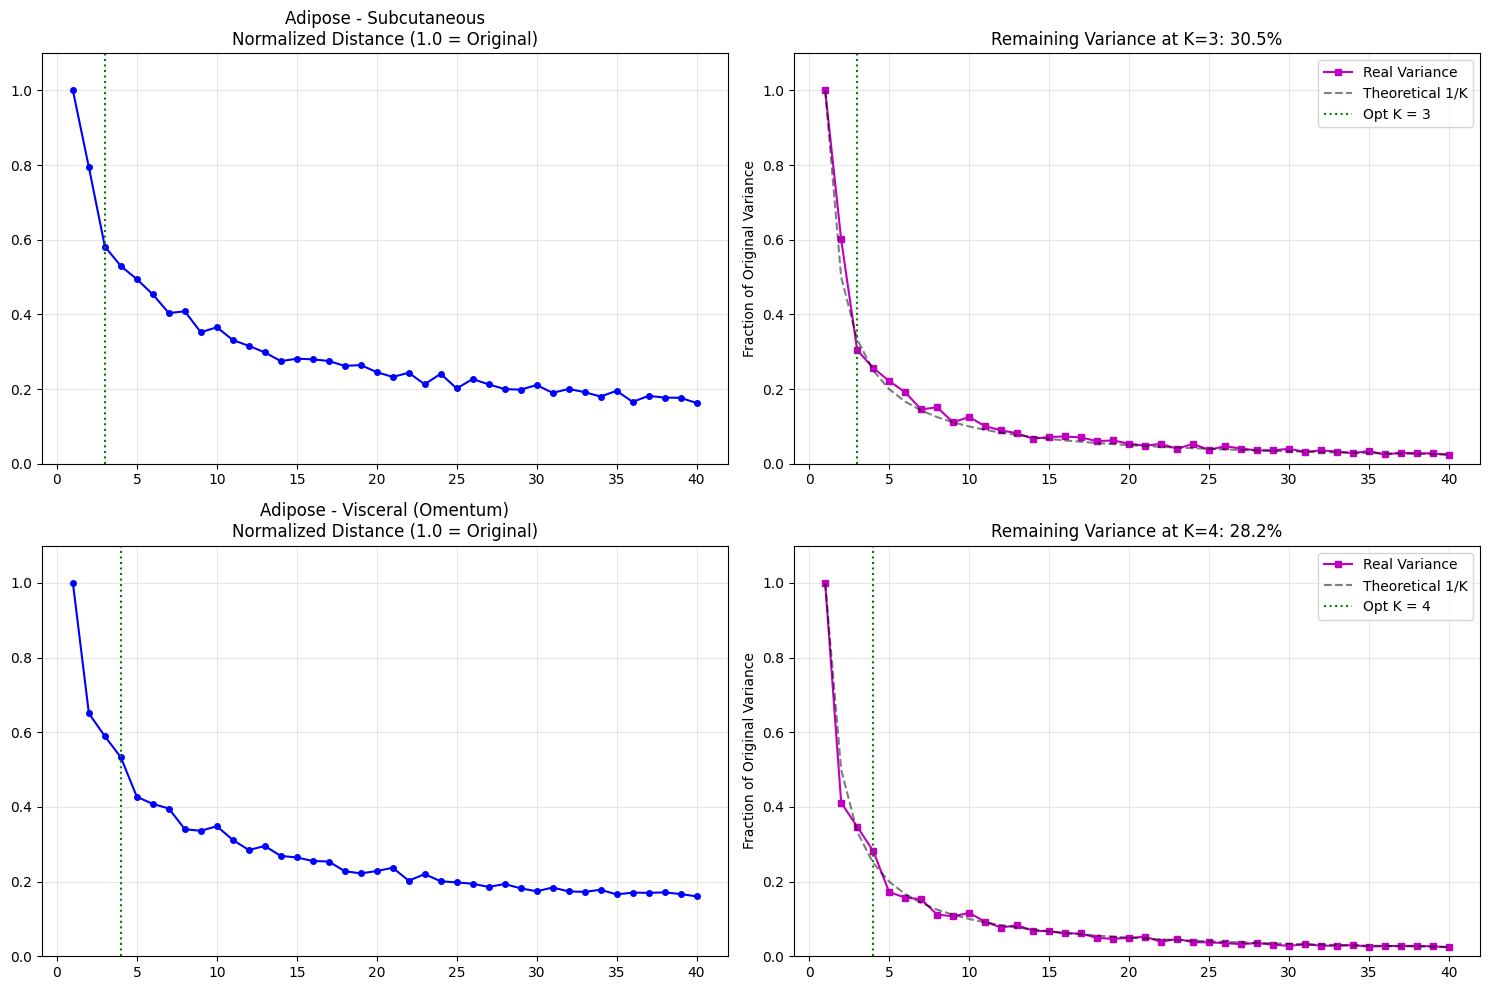

In [55]:
scripts_GTEX.plot_normalized_optimization(cpm, list(results_k.keys())[:2], results_k)

In [56]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)
scripts_GTEX.save_gtex_optimization_report(cpm, results_k, output_dir='/mnt/jack-5/amismailov/miRNA_study/figures')

Начинаю генерацию отчета для 54 тканей...
Готово! Отчет сохранен по адресу: /mnt/jack-5/amismailov/miRNA_study/figures/GTEx_K_Optimization_Results.pdf


In [57]:
import importlib, scripts_GTEX
importlib.reload(scripts_GTEX)

supplementary_table = scripts_GTEX.generate_noise_reduction_stats(cpm, results_k)
supplementary_table.to_csv('/mnt/jack-5/amismailov/miRNA_study/figures/Supplementary_Table_K_Optimization.csv', index=False)

In [208]:
tpm_gtex

,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,Adipose - Subcutaneous,...,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood,Whole Blood
ENSG00000000003,26.307469,22.456436,21.114115,18.057528,19.639415,24.092360,27.203333,25.162377,35.189425,23.220160,...,0.031300,0.072358,0.100180,0.057092,0.081885,0.077616,0.027028,0.088101,0.136807,0.129880
ENSG00000000005,7.427795,7.975482,14.043702,1.001949,73.215993,7.224560,13.262604,14.434732,12.480597,7.236549,...,0.000000,0.000000,0.015697,0.000000,0.000000,0.066890,0.011646,0.018981,0.000000,0.000000
ENSG00000000419,5.305253,5.183575,6.822804,3.674998,8.495995,5.321000,8.271423,7.932561,6.254331,8.073114,...,1.344824,1.164253,1.091789,0.964762,1.959419,3.664243,0.229387,1.910202,3.879116,0.337582
ENSG00000000457,2.430226,2.117890,2.113506,0.889838,2.572250,1.372535,2.038280,3.564665,2.056180,2.746025,...,0.353913,0.946316,0.707201,0.575550,0.956878,2.336815,0.073640,1.140205,3.141254,0.104394
ENSG00000000460,0.190675,0.190126,0.150243,0.074968,0.205216,0.110133,0.163060,0.326331,0.219952,0.261077,...,0.062017,0.110037,0.055803,0.036394,0.084228,0.043939,0.010800,0.019070,0.061295,0.006055
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000286264,0.828559,1.707732,1.678423,0.649941,2.129211,0.975302,2.884198,3.499356,1.460182,2.134847,...,0.431405,2.096918,2.433283,0.207534,1.350489,1.110938,0.057311,1.120895,0.474701,0.413111
ENSG00000286522,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.578335,5.169082,0.459250,0.411277,0.917593,0.733862,0.340728,5.275626,0.313577,0.491206
ENSG00000286920,0.034258,0.000000,0.067663,0.000000,0.022441,0.000000,0.000000,0.000000,0.000000,0.024415,...,0.000000,0.000000,0.041521,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000287080,0.398411,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.244644,3.516753,2.897242,0.432433,1.447191,0.000000,0.716510,0.000000,0.659415,0.000000


In [209]:
bootstraped_mir = scripts_GTEX.bootstrap_miRNA_adaptive(cpm, tpm_gtex.T.index, results_k)

Начинаю генерацию синтетических профилей для 19616 образцов...
Обработано 5000 образцов...
Обработано 10000 образцов...
Обработано 15000 образцов...
Сборка завершена. Итоговый размер: (19616, 327)


In [210]:
tpm_gtex = tpm_gtex.T
tpm_gtex.head(5)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
Adipose - Subcutaneous,26.307469,7.427795,5.305253,2.430226,0.190675,8.926717,9.905058,16.897223,3.348791,5.176247,...,0.0,12.990218,0.543597,0.0,0.002359,0.828559,0.0,0.034258,0.398411,0.0
Adipose - Subcutaneous,22.456436,7.975482,5.183575,2.117890,0.190126,5.668571,9.495961,15.361307,1.510903,7.519620,...,0.0,29.669689,0.425503,0.0,0.004515,1.707732,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous,21.114115,14.043702,6.822804,2.113506,0.150243,9.915179,32.681895,13.131149,1.391657,4.621651,...,0.0,46.956432,0.461478,0.0,0.006213,1.678423,0.0,0.067663,0.000000,0.0
Adipose - Subcutaneous,18.057528,1.001949,3.674998,0.889838,0.074968,20.757517,2.319972,7.420955,1.108128,2.808258,...,0.0,11.074906,0.172705,0.0,0.000000,0.649941,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous,19.639415,73.215993,8.495995,2.572250,0.205216,2.941224,18.819307,22.271523,2.106658,8.731745,...,0.0,23.681068,0.595026,0.0,0.000000,2.129211,0.0,0.022441,0.000000,0.0


In [211]:
bootstraped_mir.head(5)

,hsa-let-7a-2-3p,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7b-5p,hsa-let-7c-3p,hsa-let-7c-5p,hsa-let-7d-5p,hsa-let-7e-3p,hsa-let-7e-5p,hsa-let-7f-5p,...,hsa-mir-92a-1-5p,hsa-mir-92a-3p,hsa-mir-92b-3p,hsa-mir-93-5p,hsa-mir-95-3p,hsa-mir-96-5p,hsa-mir-98-5p,hsa-mir-99a-5p,hsa-mir-99b-3p,hsa-mir-99b-5p
Adipose - Subcutaneous,1.063561,519.138915,0.0,87720.524088,3.981025,0.0,2909.721249,39.080937,226.180552,0.0,...,116.455521,7742.582924,453.421920,634.856973,546.384043,0.000000,3859.385142,202481.654374,414.488632,10232.820363
Adipose - Subcutaneous,5.194050,200.590515,0.0,46295.831474,10.810530,0.0,2672.695562,39.966774,190.814155,0.0,...,34.336552,7552.418257,567.001879,692.489555,603.350050,1.547985,3511.374393,211116.762757,338.853263,9864.426279
Adipose - Subcutaneous,1.751956,396.717784,0.0,66104.807835,12.702184,0.0,2496.852988,28.661346,188.336777,0.0,...,61.523774,7714.785497,585.393224,706.940507,571.305739,12.314455,2767.021461,222606.866200,344.402746,8170.533544
Adipose - Subcutaneous,4.016834,238.976908,0.0,30662.406831,7.223655,0.0,2104.989869,26.663854,111.821802,0.0,...,15.330751,5944.838577,520.530164,915.397952,748.765465,51.224118,3214.363747,240968.323336,177.233390,5035.834735
Adipose - Subcutaneous,1.422387,271.140094,0.0,49964.051137,6.457044,0.0,2291.322408,21.820314,107.988820,0.0,...,52.854877,9244.585758,537.608794,561.391239,619.321737,7.616838,2799.565956,256530.281394,474.676982,8159.901849


In [212]:
assert all(bootstraped_mir.index == tpm_gtex.index)

In [213]:
new_index = (
    bootstraped_mir.index.to_series()
    + '_'
    + bootstraped_mir.index.to_series().groupby(bootstraped_mir.index).cumcount().astype(str)
)

In [214]:
new_index

Adipose - Subcutaneous    Adipose - Subcutaneous_0
Adipose - Subcutaneous    Adipose - Subcutaneous_1
Adipose - Subcutaneous    Adipose - Subcutaneous_2
Adipose - Subcutaneous    Adipose - Subcutaneous_3
Adipose - Subcutaneous    Adipose - Subcutaneous_4
                                    ...           
Whole Blood                        Whole Blood_798
Whole Blood                        Whole Blood_799
Whole Blood                        Whole Blood_800
Whole Blood                        Whole Blood_801
Whole Blood                        Whole Blood_802
Length: 19616, dtype: object

In [215]:
bootstraped_mir.index = new_index
tpm_gtex.index = new_index

In [216]:
tpm_gtex.head(5)

,ENSG00000000003,ENSG00000000005,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000000938,ENSG00000000971,ENSG00000001036,ENSG00000001084,ENSG00000001167,...,ENSG00000286140,ENSG00000286190,ENSG00000286219,ENSG00000286224,ENSG00000286237,ENSG00000286264,ENSG00000286522,ENSG00000286920,ENSG00000287080,ENSG00000287585
Adipose - Subcutaneous_0,26.307469,7.427795,5.305253,2.430226,0.190675,8.926717,9.905058,16.897223,3.348791,5.176247,...,0.0,12.990218,0.543597,0.0,0.002359,0.828559,0.0,0.034258,0.398411,0.0
Adipose - Subcutaneous_1,22.456436,7.975482,5.183575,2.117890,0.190126,5.668571,9.495961,15.361307,1.510903,7.519620,...,0.0,29.669689,0.425503,0.0,0.004515,1.707732,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous_2,21.114115,14.043702,6.822804,2.113506,0.150243,9.915179,32.681895,13.131149,1.391657,4.621651,...,0.0,46.956432,0.461478,0.0,0.006213,1.678423,0.0,0.067663,0.000000,0.0
Adipose - Subcutaneous_3,18.057528,1.001949,3.674998,0.889838,0.074968,20.757517,2.319972,7.420955,1.108128,2.808258,...,0.0,11.074906,0.172705,0.0,0.000000,0.649941,0.0,0.000000,0.000000,0.0
Adipose - Subcutaneous_4,19.639415,73.215993,8.495995,2.572250,0.205216,2.941224,18.819307,22.271523,2.106658,8.731745,...,0.0,23.681068,0.595026,0.0,0.000000,2.129211,0.0,0.022441,0.000000,0.0


In [217]:
bootstraped_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/boot_mir_mature.parquet')
tpm_gtex.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/tpm_gtex_mature.parquet')

In [220]:
bootstraped_mir.sum(axis=1)

Adipose - Subcutaneous_0    1000000.0
Adipose - Subcutaneous_1    1000000.0
Adipose - Subcutaneous_2    1000000.0
Adipose - Subcutaneous_3    1000000.0
Adipose - Subcutaneous_4    1000000.0
                              ...    
Whole Blood_798             1000000.0
Whole Blood_799             1000000.0
Whole Blood_800             1000000.0
Whole Blood_801             1000000.0
Whole Blood_802             1000000.0
Length: 19616, dtype: float64

# MERGE GTEX TCGA

In [221]:
cpm_tcga.sum(axis=0)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
TCGA-YZ-A980-01A         1000000.0
TCGA-YZ-A982-01A         1000000.0
TCGA-YZ-A983-01A         1000000.0
TCGA-YZ-A984-01A         1000000.0
TCGA-YZ-A985-01A         1000000.0
Length: 15964, dtype: float64

In [222]:
bootstraped_mir.sum(axis=1)

Adipose - Subcutaneous_0    1000000.0
Adipose - Subcutaneous_1    1000000.0
Adipose - Subcutaneous_2    1000000.0
Adipose - Subcutaneous_3    1000000.0
Adipose - Subcutaneous_4    1000000.0
                              ...    
Whole Blood_798             1000000.0
Whole Blood_799             1000000.0
Whole Blood_800             1000000.0
Whole Blood_801             1000000.0
Whole Blood_802             1000000.0
Length: 19616, dtype: float64

In [225]:
bootstraped_mir = bootstraped_mir.T
bootstraped_mir.head(5)

,Adipose - Subcutaneous_0,Adipose - Subcutaneous_1,Adipose - Subcutaneous_2,Adipose - Subcutaneous_3,Adipose - Subcutaneous_4,Adipose - Subcutaneous_5,Adipose - Subcutaneous_6,Adipose - Subcutaneous_7,Adipose - Subcutaneous_8,Adipose - Subcutaneous_9,...,Whole Blood_793,Whole Blood_794,Whole Blood_795,Whole Blood_796,Whole Blood_797,Whole Blood_798,Whole Blood_799,Whole Blood_800,Whole Blood_801,Whole Blood_802
hsa-let-7a-2-3p,1.063561,5.194050,1.751956,4.016834,1.422387,0.000000,3.752220,1.743286,1.208691,0.000000,...,0.000000,0.983338,0.000000,0.000000,0.000000,0.000000,0.000000,1.069785,0.000000,0.000000
hsa-let-7a-3p,519.138915,200.590515,396.717784,238.976908,271.140094,273.445259,264.605718,424.006531,346.825906,491.071629,...,30.237568,81.841143,41.116447,21.825260,83.628276,45.907937,52.687854,70.678903,123.502757,83.653481
hsa-let-7a-5p,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b-5p,87720.524088,46295.831474,66104.807835,30662.406831,49964.051137,65053.584700,66351.754199,73858.881951,76801.727453,70454.043194,...,30643.250290,19727.626431,21334.837448,19012.644059,22577.906231,38048.825142,18068.663485,19890.860743,11720.103257,13544.940260
hsa-let-7c-3p,3.981025,10.810530,12.702184,7.223655,6.457044,10.450875,11.051589,12.496342,14.512402,14.968673,...,0.000000,0.911113,0.000000,0.000000,0.555999,0.000000,0.000000,0.000000,0.000000,0.000000


In [226]:
cpm_tcga.head()

,BLGSP-71-06-00001-01A,BLGSP-71-06-00001-01B,BLGSP-71-06-00002-01C,BLGSP-71-06-00002-01D,BLGSP-71-06-00004-01A,BLGSP-71-06-00004-01B,BLGSP-71-06-00005-01A,BLGSP-71-06-00005-01B,BLGSP-71-06-00007-01A,BLGSP-71-06-00007-01B,...,TCGA-WC-A885-01A,TCGA-WC-A888-01A,TCGA-WC-A88A-01A,TCGA-WC-AA9A-01A,TCGA-WC-AA9E-01A,TCGA-YZ-A980-01A,TCGA-YZ-A982-01A,TCGA-YZ-A983-01A,TCGA-YZ-A984-01A,TCGA-YZ-A985-01A
miRNA_ID,,,,,,,,,,,,,,,,,,,,,
hsa-let-7a-2-3p,1.586508,6.942034,1.130046,0.000000,2.524994,2.656191,1.411532,0.000000,0.755251,4.726641,...,4.027038,2.972231,0.418747,0.000000,0.000000,2.018722,0.347579,0.000000,5.166802,0.000000
hsa-let-7a-3p,53.764981,33.321763,47.838608,54.311141,133.572198,53.123813,89.329807,66.048017,71.295701,55.538028,...,20.806361,59.714817,42.712244,54.905681,27.845056,4.129203,18.074113,14.147240,13.910621,15.210867
hsa-let-7a-5p,62936.581561,46808.746963,75802.346691,38974.339649,95529.118865,54706.902643,58124.868551,19715.333047,87308.534413,40051.189518,...,165650.175277,80435.318315,200407.943807,128801.369359,122022.008534,30779.265086,159970.845066,89856.193308,127370.022134,115248.268198
hsa-let-7b-5p,15862.079603,10819.854217,4194.541916,2973.812055,8227.693885,5499.642742,6881.419824,5779.201479,6316.164714,4632.107834,...,27618.094553,29622.872558,49637.071548,69423.422424,20519.320243,15905.966479,70093.842880,18840.979523,55098.381877,60169.270111
hsa-let-7c-3p,1.850926,2.776814,2.825115,7.758734,3.787491,3.984286,4.637891,0.000000,4.682557,10.634941,...,72.822262,20.805615,9.212445,5.094342,55.192879,23.857619,53.874760,51.873212,91.412655,141.818969


In [227]:
assert all(bootstraped_mir.index == cpm_tcga.index)

In [ ]:
merged_mir = pd.concat([cpm_tcga, bootstraped_mir], axis=1)
merged_mir.sum(axis=0)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
Whole Blood_798          1000000.0
Whole Blood_799          1000000.0
Whole Blood_800          1000000.0
Whole Blood_801          1000000.0
Whole Blood_802          1000000.0
Length: 35580, dtype: float64

In [235]:
# merge mRNA
tpm_gtex = tpm_gtex.T
assert all(tpm_tcga.index == tpm_gtex.index)

In [236]:
merged_rna = pd.concat([tpm_tcga, tpm_gtex], axis=1)
merged_rna.sum(axis=0)

BLGSP-71-06-00001-01A    1000000.0
BLGSP-71-06-00001-01B    1000000.0
BLGSP-71-06-00002-01C    1000000.0
BLGSP-71-06-00002-01D    1000000.0
BLGSP-71-06-00004-01A    1000000.0
                           ...    
Whole Blood_798          1000000.0
Whole Blood_799          1000000.0
Whole Blood_800          1000000.0
Whole Blood_801          1000000.0
Whole Blood_802          1000000.0
Length: 35580, dtype: float64

In [239]:
merged_rna.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/merged_rna_mature.parquet')
merged_mir.to_parquet('/mnt/jack-5/amismailov/miRNA_study/PROPER_NORMALIZED_DATASETS/NEW/merged_mir_mature.parquet')

In [240]:
del tpm_tcga, tpm_gtex, cpm, cpm_tcga
gc.collect()

0